<a href="https://colab.research.google.com/github/prathamj937/email_spam/blob/main/Email_spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Desktop\emai\Spam Email Detection - spam.csv")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
# Data Cleaning

In [3]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"],inplace=True)

In [4]:
df.rename(columns={'v1': 'target', 'v2': 'data'}, inplace=True)
df.head()

,target,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit_transform(df['target'])

array([0, 0, 1, ..., 0, 0, 0])

In [6]:
df.head()

,target,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.isnull().sum() # no missing values

target    0
data      0
dtype: int64

In [8]:
df.duplicated().sum()

409

In [9]:
df.drop_duplicates(keep='first')

,target,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will �_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [10]:
# Exploratory Data Analysis

In [11]:
import matplotlib.pyplot as plt
import seaborn

([<matplotlib.patches.Wedge at 0x1ee8155ef90>,
 [Text(0.4799400721489948, -0.9897765036338344, 'ham'),
  Text(-0.4799400258142125, 0.9897765261014495, 'spam')],
 [Text(0.26178549389945166, -0.5398780928911824, '86.6%'),
  Text(-0.26178546862593405, 0.5398781051462451, '13.4%')])

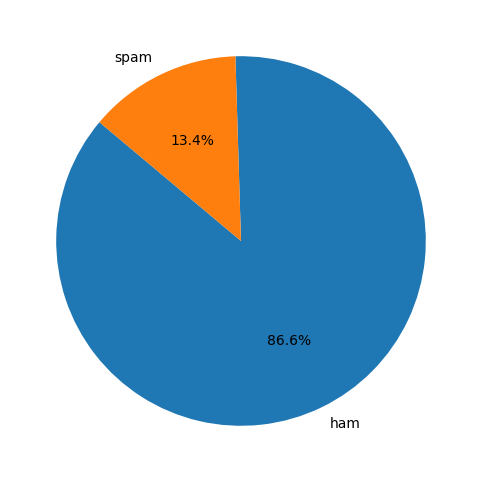

In [12]:
target_counts = df['target'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140)

In [13]:
df['num_characters'] = df['data'].apply(len)
df.head()

,target,data,num_characters
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [16]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [17]:
df["num_words"] = df["data"].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,target,data,num_characters,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [18]:
from nltk.tokenize import sent_tokenize
df["num_sentences"] = df["data"].apply(lambda x: len(sent_tokenize(x)))
df.head()

,target,data,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [19]:
# Data Pre-Processing
from nltk.stem import PorterStemmer
ps = PorterStemmer()
nltk.download('stopwords')
import string
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
def transform_text(data):
  if isinstance(data, str):
    data = data.lower()
    data = nltk.word_tokenize(data)
    y=[]
    for i in data:
      if i.isalnum():
        y.append(i)
    data = y[:]
    y.clear()
    for i in data:
      if i not in stopwords.words("english") and i not in string.punctuation:
        y.append(i)
    text = y[:]
    y.clear()
    for i in text:
      y.append(ps.stem(i))
    return " ".join(y)
  else:
    return ""


In [21]:
df["transformed_text"] = df["data"].apply(transform_text)
df.head()

,target,data,num_characters,num_words,num_sentences,transformed_text
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [22]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [23]:
X = cv.fit_transform(df["transformed_text"]).toarray()
y = df["target"].values

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [25]:
# I am using Naives Bayes Model for this as its a textual data and this model is suitable to that

In [26]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [27]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [28]:
gnb.fit(X_train,y_train)
y_pred = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test, y_pred, pos_label='spam'))
print(confusion_matrix(y_test,y_pred))

0.8717488789237668
0.5303643724696356
[[841 116]
 [ 27 131]]


In [29]:
mnb.fit(X_train,y_train)
y_pred = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test, y_pred, pos_label='spam'))
print(confusion_matrix(y_test,y_pred))

0.9721973094170404
0.9096774193548387
[[943  14]
 [ 17 141]]


In [30]:
bnb.fit(X_train,y_train)
y_pred = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test, y_pred, pos_label='spam'))
print(confusion_matrix(y_test,y_pred))

0.9695067264573991
0.9920634920634921
[[956   1]
 [ 33 125]]


In [31]:
# Highest precision score is of Bernoulli naives bayes model

In [32]:
# from three models we can see that bernoulli naive bayes is
# the most suitable beacuse its precision is high

In [36]:
def predict_email(email):
    X_email = cv.transform([email])
    prediction = bnb.predict(X_email)

    return prediction[0]

In [37]:
new_email = input("Enter a new email to predict: ")
prediction = predict_email(new_email)
print("Prediction:", prediction)

Prediction: ham


In [39]:
import joblib

# Save the trained model
joblib.dump(bnb, "email_spam_classifier.pkl")

# Save the vectorizer
joblib.dump(cv, "vectorizer.pkl")

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [40]:
import joblib

# Load the saved model
bnb_loaded = joblib.load("email_spam_classifier.pkl")

# Load the saved vectorizer
cv_loaded = joblib.load("vectorizer.pkl")

# Predict function using reloaded model and vectorizer
def predict_email(email):
    X_email = cv_loaded.transform([email])
    prediction = bnb_loaded.predict(X_email)
    return prediction[0]

# Test the function
test_email = "Congratulations! You have won a lottery. Claim now."
result = predict_email(test_email)
print("Prediction:", "Spam" if result == 'spam' else "Not Spam")


Prediction: Not Spam
